In [ ]:
# =====================================================
# CUSTOMER LIFETIME VALUE PREDICTION PROJECT
# =====================================================

#Step 1 — Install Required Libraries
!pip install pandas numpy scikit-learn matplotlib seaborn xgboost

In [ ]:

# Step 2. Import Required Libraries

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.model_selection import RandomizedSearchCV

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor

from sklearn.cluster import KMeans

from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score

from xgboost import XGBRegressor




In [ ]:
#Step 3 Load Dataset
df = pd.read_csv("customer_lifetime_value.csv")

df.head()

,Customer,State,Customer Lifetime Value,Response,Coverage,Education,Effective To Date,EmploymentStatus,Gender,Income,...,Months Since Policy Inception,Number of Open Complaints,Number of Policies,Policy Type,Policy,Renew Offer Type,Sales Channel,Total Claim Amount,Vehicle Class,Vehicle Size
0,BU79786,Washington,2763.519279,No,Basic,Bachelor,2/24/11,Employed,F,56274,...,5,0,1,Corporate Auto,Corporate L3,Offer1,Agent,384.811147,Two-Door Car,Medsize
1,QZ44356,Arizona,6979.535903,No,Extended,Bachelor,1/31/11,Unemployed,F,0,...,42,0,8,Personal Auto,Personal L3,Offer3,Agent,1131.464935,Four-Door Car,Medsize
2,AI49188,Nevada,12887.431650,No,Premium,Bachelor,2/19/11,Employed,F,48767,...,38,0,2,Personal Auto,Personal L3,Offer1,Agent,566.472247,Two-Door Car,Medsize
3,WW63253,California,7645.861827,No,Basic,Bachelor,1/20/11,Unemployed,M,0,...,65,0,7,Corporate Auto,Corporate L2,Offer1,Call Center,529.881344,SUV,Medsize
4,HB64268,Washington,2813.692575,No,Basic,Bachelor,2/3/11,Employed,M,43836,...,44,0,1,Personal Auto,Personal L1,Offer1,Agent,138.130879,Four-Door Car,Medsize


In [ ]:
#Check dataset info:

df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9134 entries, 0 to 9133
Data columns (total 24 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Customer                       9134 non-null   object 
 1   State                          9134 non-null   object 
 2   Customer Lifetime Value        9134 non-null   float64
 3   Response                       9134 non-null   object 
 4   Coverage                       9134 non-null   object 
 5   Education                      9134 non-null   object 
 6   Effective To Date              9134 non-null   object 
 7   EmploymentStatus               9134 non-null   object 
 8   Gender                         9134 non-null   object 
 9   Income                         9134 non-null   int64  
 10  Location Code                  9134 non-null   object 
 11  Marital Status                 9134 non-null   object 
 12  Monthly Premium Auto           9134 non-null   i

,Customer Lifetime Value,Income,Monthly Premium Auto,Months Since Last Claim,Months Since Policy Inception,Number of Open Complaints,Number of Policies,Total Claim Amount
count,9134.000000,9134.000000,9134.000000,9134.000000,9134.000000,9134.000000,9134.000000,9134.000000
mean,8004.940475,37657.380009,93.219291,15.097000,48.064594,0.384388,2.966170,434.088794
std,6870.967608,30379.904734,34.407967,10.073257,27.905991,0.910384,2.390182,290.500092
min,1898.007675,0.000000,61.000000,0.000000,0.000000,0.000000,1.000000,0.099007
25%,3994.251794,0.000000,68.000000,6.000000,24.000000,0.000000,1.000000,272.258244
50%,5780.182197,33889.500000,83.000000,14.000000,48.000000,0.000000,2.000000,383.945434
75%,8962.167041,62320.000000,109.000000,23.000000,71.000000,0.000000,4.000000,547.514839
max,83325.381190,99981.000000,298.000000,35.000000,99.000000,5.000000,9.000000,2893.239678


In [ ]:
#Step 4 Data Cleaning

#Remove unnecessary column:
df.drop("Customer", axis=1, inplace=True)

In [ ]:
# check missing values
print("\nNumber of missing values per column:")
display(df.isnull().sum())


Number of missing values per column:


,0
State,0
Customer Lifetime Value,0
Response,0
Coverage,0
Education,0
Effective To Date,0
EmploymentStatus,0
Gender,0
Income,0
Location Code,0


In [ ]:
#Convert date column:
df['Effective To Date'] = pd.to_datetime(df['Effective To Date'], format='%m/%d/%y')

In [ ]:
#Extract useful features:
df['month'] = df['Effective To Date'].dt.month
df['year'] = df['Effective To Date'].dt.year

In [ ]:
#Drop original Date
df = df.drop(columns=['Effective To Date'])
display(df.head())

,State,Customer Lifetime Value,Response,Coverage,Education,EmploymentStatus,Gender,Income,Location Code,Marital Status,...,Number of Policies,Policy Type,Policy,Renew Offer Type,Sales Channel,Total Claim Amount,Vehicle Class,Vehicle Size,month,year
0,Washington,2763.519279,No,Basic,Bachelor,Employed,F,56274,Suburban,Married,...,1,Corporate Auto,Corporate L3,Offer1,Agent,384.811147,Two-Door Car,Medsize,2,2011
1,Arizona,6979.535903,No,Extended,Bachelor,Unemployed,F,0,Suburban,Single,...,8,Personal Auto,Personal L3,Offer3,Agent,1131.464935,Four-Door Car,Medsize,1,2011
2,Nevada,12887.431650,No,Premium,Bachelor,Employed,F,48767,Suburban,Married,...,2,Personal Auto,Personal L3,Offer1,Agent,566.472247,Two-Door Car,Medsize,2,2011
3,California,7645.861827,No,Basic,Bachelor,Unemployed,M,0,Suburban,Married,...,7,Corporate Auto,Corporate L2,Offer1,Call Center,529.881344,SUV,Medsize,1,2011
4,Washington,2813.692575,No,Basic,Bachelor,Employed,M,43836,Rural,Single,...,1,Personal Auto,Personal L1,Offer1,Agent,138.130879,Four-Door Car,Medsize,2,2011


In [ ]:
#Step 5 Feature Engineering

#Create new features that improve model performance.

#Policy Age
df["policy_age"] = current_year - df["year"]
#Claim Ratio
df["claim_ratio"] = df["Total Claim Amount"] / (df["Monthly Premium Auto"] + 1)
df["income_level"] = pd.qcut(df["Income"], 3, labels=[1,2,3], duplicates='drop')

In [ ]:
# Step 6 Handle Categorical Variables
df = pd.get_dummies(df, drop_first=True)

In [ ]:
df["income_level"] = df["income_level"].astype(int)

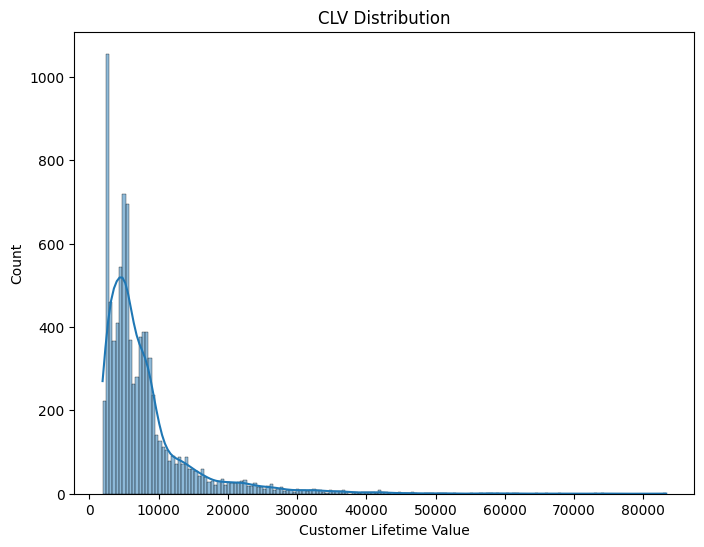

In [ ]:
#step 7  Exploratory Data Analysis

#CLV Distribution
plt.figure(figsize=(8,6))

sns.histplot(df["Customer Lifetime Value"], kde=True)

plt.title("CLV Distribution")

plt.show()

In [ ]:
#Step 8 — Define Features and Target
X = df.drop("Customer Lifetime Value", axis=1)

y = df["Customer Lifetime Value"]

In [ ]:
#Step 9 — Train Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
#Step 10 — Train and Evaluate Multiple Models

from sklearn.pipeline import Pipeline

models = {
    "Linear Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LinearRegression())
    ]),
    "Random Forest": RandomForestRegressor(n_estimators=200, random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(),
    "XGBoost": XGBRegressor(objective='reg:squarederror')
}

results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    results.append([name, rmse, mae, r2])

results_df = pd.DataFrame(results, columns=["Model","RMSE","MAE","R2"])
print("\nModel Comparison:\n", results_df.sort_values(by="R2", ascending=False))



Model Comparison:
                Model         RMSE          MAE        R2
1      Random Forest  3990.858713  1470.415957  0.690956
2  Gradient Boosting  4130.972507  1741.380166  0.668874
3            XGBoost  4288.308761  1898.598654  0.643171
0  Linear Regression  6597.803909  3997.243944  0.155330



Comparing the three models, the Random Forest Regressor demonstrated the best performance, achieving the lowest MAE and RMSE, and the highest R-squared value of 0.69. This indicates that the Random Forest model provides the most accurate predictions for Customer Lifetime Value among the tested models, capturing more of the underlying patterns and non-linear relationships in the data. While XGBoost also performed significantly better than Linear Regression, the Random Forest proved to be marginally superior in this specific context.



In [ ]:
# STEP 11: Hyperparameter Tuning (Random Forest)
# =====================================================
param_grid = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [None, 5, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']
}

rf = RandomForestRegressor(random_state=42, n_jobs=-1)

search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_grid,
    n_iter=20,
    cv=3,
    verbose=1,
    n_jobs=-1,
    scoring='r2',
    random_state=42,
    return_train_score=True
)

search.fit(X_train, y_train)

best_model = search.best_estimator_

print("\nBest Parameters:", search.best_params_)
print("Best CV Score:", search.best_score_)

# Evaluate tuned model
y_pred = best_model.predict(X_test)

print("\nBest Model Performance:")
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("MAE:", mean_absolute_error(y_test, y_pred))
print("R2:", r2_score(y_test, y_pred))

# Overfitting Check
print("\nTrain Score:", best_model.score(X_train, y_train))
print("Test Score:", best_model.score(X_test, y_test))


Fitting 3 folds for each of 20 candidates, totalling 60 fits

Best Parameters: {'n_estimators': 100, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'max_depth': 30}
Best CV Score: 0.6041891901816907

Best Model Performance:
RMSE: 4523.659744924945
MAE: 1988.0366328687605
R2: 0.6029292198656664

Train Score: 0.8595864405585882
Test Score: 0.6029292198656664


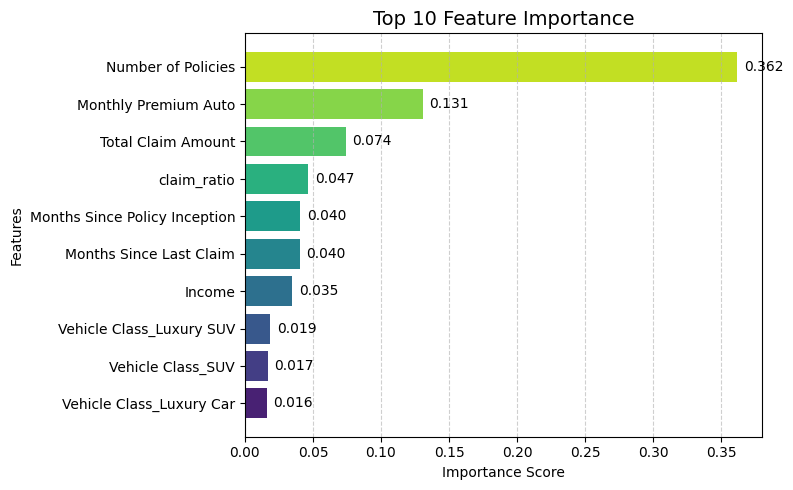

In [ ]:
#Step 12 — Feature Importance

# Create importance series
importance = pd.Series(best_model.feature_importances_, index=X.columns)
# Sort top 10 ascending for better visual order

top10 = importance.sort_values(ascending=True).tail(10)

# Create gradient colors
colors = sns.color_palette("viridis", len(top10))

plt.figure(figsize=(8, 5))

bars = plt.barh(top10.index, top10.values, color=colors)

plt.title("Top 10 Feature Importance", fontsize=14)
plt.xlabel("Importance Score")
plt.ylabel("Features")

# Add value labels
for i, v in enumerate(top10.values):
    plt.text(v + 0.005, i, f"{v:.3f}", va='center')

plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

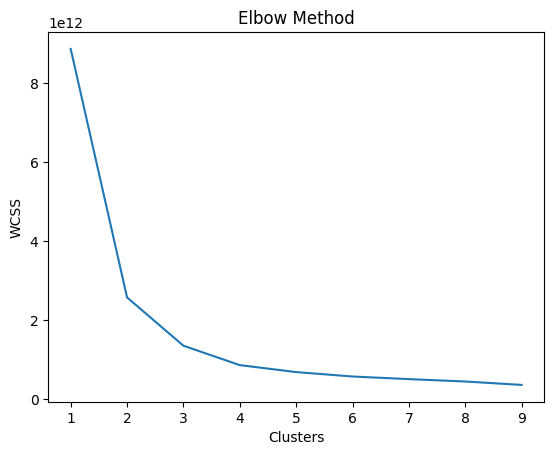

In [ ]:
#STEP 13: Customer Segmentation (Elbow Method)
# =====================================================
seg_features = df[[
    "Customer Lifetime Value",
    "Income",
    "Monthly Premium Auto"
]]

wcss = []
for i in range(1, 10):
    km = KMeans(n_clusters=i, random_state=42)
    km.fit(seg_features)
    wcss.append(km.inertia_)

plt.plot(range(1,10), wcss)
plt.title("Elbow Method")
plt.xlabel("Clusters")
plt.ylabel("WCSS")
plt.show()

In [ ]:
seg_features = df[[
    "Customer Lifetime Value",
    "Income",
    "Monthly Premium Auto"
]]

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
seg_scaled = scaler.fit_transform(seg_features)

kmeans = KMeans(n_clusters=3, random_state=42)
df["customer_segment"] = kmeans.fit_predict(seg_scaled)

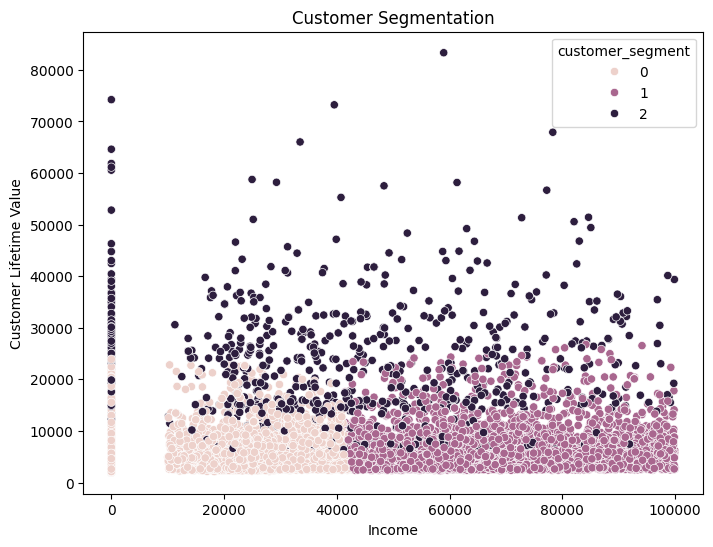

In [ ]:
# STEP 14: Segment Visualization
# =====================================================
plt.figure(figsize=(8,6))
sns.scatterplot(
    x="Income",
    y="Customer Lifetime Value",
    hue="customer_segment",
    data=df
)
plt.title("Customer Segmentation")
plt.show()




In [ ]:
segment_summary = df.groupby("customer_segment").mean(numeric_only=True)
segment_summary = segment_summary.sort_values(by="Customer Lifetime Value", ascending=True)
for i, row in segment_summary.iterrows():
    print(f"\nSegment {i}:")
    print(f"Avg CLV: {row['Customer Lifetime Value']:.2f}")
    print(f"Avg Income: {row['Income']:.2f}")


Segment 0:
Avg CLV: 6263.99
Avg Income: 15145.95

Segment 1:
Avg CLV: 6695.84
Avg Income: 68912.34

Segment 2:
Avg CLV: 21017.85
Avg Income: 36075.32
